In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 10)

## Load photon times data

In [ ]:
# Load photon arrival times (values are in microseconds even if the file header says ns)
df_photons = pd.read_csv('/Users/pablovazquez/GALA_hole/build/photon_times.txt', sep='\t')

if 'photon_time_ns' in df_photons.columns:
    df_photons = df_photons.rename(columns={'photon_time_ns': 'photon_time_us'})

print(f"Loaded {len(df_photons)} photon events")
print(f"\nColumns: {list(df_photons.columns)}")
print(f"\nFirst rows:")
print(df_photons.head(20))

print(f"\nPhoton time statistics:")
print(f"  Min time: {df_photons['photon_time_us'].min():.3f} us")
print(f"  Max time: {df_photons['photon_time_us'].max():.3f} us")
print(f"  Mean time: {df_photons['photon_time_us'].mean():.3f} us")
print(f"  Std time: {df_photons['photon_time_us'].std():.3f} us")

Loaded 28554085 photon events

Columns: ['event_id', 'photon_time_us']

First rows:
    event_id  photon_time_us
0          0         5.27486
1          0         7.00440
2          0         6.24176
3          0         6.18777
4          0         6.12759
5          0         4.16717
6          0         6.14622
7          0         6.16131
8          0         6.22834
9          0         6.16366
10         0         5.79306
11         0         6.21706
12         0         7.82568
13         0         6.42654
14         0         5.75908
15         0         5.98144
16         0         5.77034
17         0         6.08286
18         0         4.89140
19         0         5.48891

Photon time statistics:
  Min time: 1.643 us
  Max time: 10.291 us
  Mean time: 6.098 us
  Std time: 0.798 us


## SiPM Parameters

In [ ]:
# Parámetros del SiPM
kPDE = 0.30              # 30% PDE
kCrossTalkProb = 0.07    # 7% crosstalk
kMicrocells = 4774       # Total de microceldas
kDarkCountRateHz = 860.0e3  # 860 kHz dark count rate
kBinWidth = 1.0e-6       # 1 us bin width
kNumBins = 400           # 400 bins
kRecoveryTauNs = 82.0    # tiempo de recuperación de microceldas
kRecoveryTauUs = kRecoveryTauNs * 1e-3

print(f"SiPM Configuration:")
print(f"  PDE: {kPDE*100}%")
print(f"  Crosstalk probability: {kCrossTalkProb*100}%")
print(f"  Total microcells: {kMicrocells}")
print(f"  Dark count rate: {kDarkCountRateHz/1e3:.0f} kHz")
print(f"  Bin width: {kBinWidth*1e6:.1f} us")
print(f"  Total window: {kNumBins * kBinWidth * 1e6:.0f} us")
print(f"  Recovery tau: {kRecoveryTauNs:.1f} ns")

SiPM Configuration:
  PDE: 30.0%
  Crosstalk probability: 7.000000000000001%
  Total microcells: 4774
  Dark count rate: 860 kHz
  Bin width: 1.0 us
  Total window: 400 us
  Recovery tau: 82.0 ns


## Bin photons temporally and calculate saturation

In [4]:
# Recovery-aware SiPM model
# Each photon is processed in time order, with microcell recovery modeled as an exponential.

rng = np.random.default_rng(12345)

def try_fire_cell(last_fire_times, cell_idx, t_us, tau_us):
    t_last = last_fire_times[cell_idx]
    if not np.isfinite(t_last):
        recovery = 1.0
    else:
        dt = t_us - t_last
        if dt <= 0.0:
            recovery = 0.0
        else:
            recovery = 1.0 - np.exp(-dt / tau_us)
    if rng.random() < recovery:
        last_fire_times[cell_idx] = t_us
        return True, recovery
    return False, recovery

# Group photons by event
events = df_photons.groupby('event_id')
print(f"Total events: {len(events)}")

# Storage for results
saturation_results = []

for event_id, group in events:
    photon_times = np.sort(group['photon_time_us'].to_numpy())

    # Build a 1 us-bin view for reference and plotting
    bins = np.arange(0, kNumBins + 1) * kBinWidth * 1e6  # us
    photons_per_bin, _ = np.histogram(photon_times, bins=bins)

    # Dark counts sampled inside the full acquisition window
    expected_dark = kDarkCountRateHz * kBinWidth * kNumBins
    n_dark = rng.poisson(expected_dark)
    dark_times = rng.random(n_dark) * (kNumBins * kBinWidth * 1e6) if n_dark > 0 else np.array([])

    # Merge photon + dark times and process chronologically
    all_times = np.concatenate([photon_times, dark_times]) if n_dark > 0 else photon_times
    all_times.sort()

    # Microcell state: last time each cell fired (us)
    last_fire = np.full(kMicrocells, -np.inf)

    # Per-bin outputs
    n_final_per_bin = np.zeros(kNumBins, dtype=int)
    n_primary_per_bin = np.zeros(kNumBins, dtype=int)
    n_crosstalk_per_bin = np.zeros(kNumBins, dtype=int)
    n_rejected_by_recovery = np.zeros(kNumBins, dtype=int)

    for t_us in all_times:
        bin_idx = int(t_us // 1.0)
        if bin_idx < 0 or bin_idx >= kNumBins:
            continue

        # PDE at photon level
        if rng.random() >= kPDE:
            continue

        # Primary avalanche on a random microcell
        cell = rng.integers(0, kMicrocells)
        fired, recovery = try_fire_cell(last_fire, cell, t_us, kRecoveryTauUs)
        if not fired:
            n_rejected_by_recovery[bin_idx] += 1
            continue

        n_primary_per_bin[bin_idx] += 1
        n_final_per_bin[bin_idx] += 1

        # Simple 1st-generation crosstalk (one extra attempt)
        if rng.random() < kCrossTalkProb:
            cell_ct = rng.integers(0, kMicrocells - 1)
            if cell_ct >= cell:
                cell_ct += 1
            fired_ct, recovery_ct = try_fire_cell(last_fire, cell_ct, t_us, kRecoveryTauUs)
            if fired_ct:
                n_crosstalk_per_bin[bin_idx] += 1
                n_final_per_bin[bin_idx] += 1
            else:
                n_rejected_by_recovery[bin_idx] += 1

    # Saturation metrics
    sat_ratio = (n_final_per_bin / kMicrocells) * 100.0
    total_npe = int(n_final_per_bin.sum())
    total_charge = float(total_npe)

    for bin_idx, n_photons in enumerate(photons_per_bin):
        if n_photons == 0 and n_final_per_bin[bin_idx] == 0:
            continue

        n_primary = int(n_primary_per_bin[bin_idx])
        n_after_sat = min(n_primary, kMicrocells)
        n_ct = int(n_crosstalk_per_bin[bin_idx])
        n_after_ct = min(n_after_sat + n_ct, kMicrocells)
        fully_filled = bool(n_final_per_bin[bin_idx] >= kMicrocells)

        saturation_results.append({
            'event_id': int(event_id),
            'bin_idx': int(bin_idx),
            'bin_time_us': float(bin_idx),
            'n_photons': int(n_photons),
            'n_primary': n_primary,
            'n_after_sat': n_after_sat,
            'n_crosstalk': n_ct,
            'n_after_ct': n_after_ct,
            'n_dark': int(n_dark),
            'n_final': int(n_final_per_bin[bin_idx]),
            'sat_ratio': float(sat_ratio[bin_idx]),
            'rejected_by_recovery': int(n_rejected_by_recovery[bin_idx]),
            'fully_filled': fully_filled,
        })

df_saturation = pd.DataFrame(saturation_results)
print(f"\nProcessed {len(df_saturation)} bin entries")
print(f"\nFirst saturation results:")
print(df_saturation.head(10))
print(f"\nRecovery tau used: {kRecoveryTauNs:.1f} ns")

Total events: 1000

Processed 96779 bin entries

First saturation results:
   event_id  bin_idx  bin_time_us  n_photons  n_primary  n_after_sat  \
0         0        3          3.0        118         37           37   
1         0        4          4.0       2012        597          597   
2         0        5          5.0       9074       2662         2662   
3         0        6          6.0      10641       2993         2993   
4         0        7          7.0       3022        878          878   
5         0        8          8.0        197         72           72   
6         0        9          9.0          3          2            2   
7         0       17         17.0          0          1            1   
8         0       18         18.0          0          1            1   
9         0       31         31.0          0          1            1   

   n_crosstalk  n_after_ct  n_dark  n_final  sat_ratio  rejected_by_recovery  \
0            0          37     328       37   0.7750

## Saturation Statistics

In [5]:
print("=== SATURATION STATISTICS ===")
print(f"\nBins fully filled (nPE >= {kMicrocells}): {df_saturation['fully_filled'].sum()}")
print(f"Bins rejected by recovery (accumulated over entries): {df_saturation['rejected_by_recovery'].sum() if 'rejected_by_recovery' in df_saturation.columns else 0}")

print(f"\nSaturation ratio statistics:")
print(f"  Max: {df_saturation['sat_ratio'].max():.2f}%")
print(f"  Mean: {df_saturation['sat_ratio'].mean():.2f}%")
print(f"  Median: {df_saturation['sat_ratio'].median():.2f}%")
print(f"  Std: {df_saturation['sat_ratio'].std():.2f}%")

print(f"\nPhotons per bin statistics:")
print(f"  Max: {df_saturation['n_photons'].max()}")
print(f"  Mean: {df_saturation['n_photons'].mean():.2f}")
print(f"  Median: {df_saturation['n_photons'].median():.0f}")

print(f"\nFinal nPE per bin statistics:")
print(f"  Max: {df_saturation['n_final'].max()}")
print(f"  Mean: {df_saturation['n_final'].mean():.2f}")
print(f"  Median: {df_saturation['n_final'].median():.0f}")
print(f"\nRecovery tau: {kRecoveryTauNs:.1f} ns")

=== SATURATION STATISTICS ===

Bins fully filled (nPE >= 4774): 0
Bins rejected by recovery (accumulated over entries): 464939

Saturation ratio statistics:
  Max: 92.12%
  Mean: 1.90%
  Median: 0.02%
  Std: 10.44%

Photons per bin statistics:
  Max: 14646
  Mean: 295.04
  Median: 0

Final nPE per bin statistics:
  Max: 4398
  Mean: 90.71
  Median: 1

Recovery tau: 82.0 ns


## Visualizations

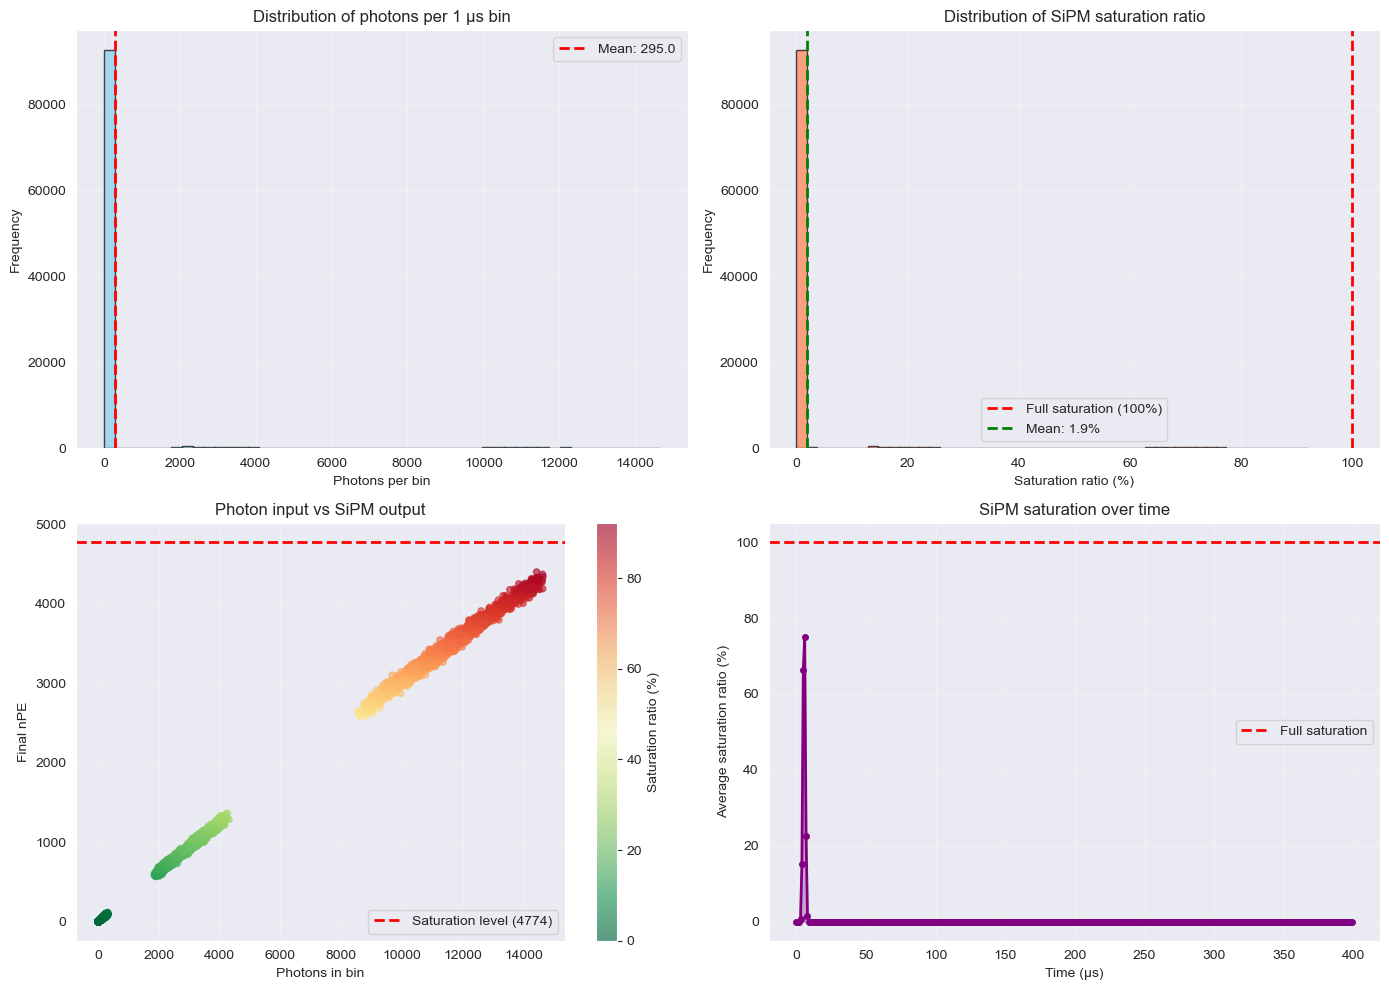

Figures saved


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of photons per bin
ax = axes[0, 0]
ax.hist(df_saturation['n_photons'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(df_saturation['n_photons'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_saturation['n_photons'].mean():.1f}")
ax.set_xlabel('Photons per bin')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of photons per 1 μs bin')
ax.legend()
ax.grid(alpha=0.3)

# 2. Saturation ratio histogram
ax = axes[0, 1]
ax.hist(df_saturation['sat_ratio'], bins=50, alpha=0.7, color='coral', edgecolor='black')
ax.axvline(100, color='red', linestyle='--', linewidth=2, label='Full saturation (100%)')
ax.axvline(df_saturation['sat_ratio'].mean(), color='green', linestyle='--', linewidth=2, label=f"Mean: {df_saturation['sat_ratio'].mean():.1f}%")
ax.set_xlabel('Saturation ratio (%)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of SiPM saturation ratio')
ax.legend()
ax.grid(alpha=0.3)

# 3. Photons vs final nPE
ax = axes[1, 0]
h = ax.scatter(df_saturation['n_photons'], df_saturation['n_final'], 
               c=df_saturation['sat_ratio'], cmap='RdYlGn_r', alpha=0.6, s=20)
ax.axhline(kMicrocells, color='red', linestyle='--', linewidth=2, label=f'Saturation level ({kMicrocells})')
ax.set_xlabel('Photons in bin')
ax.set_ylabel('Final nPE')
ax.set_title('Photon input vs SiPM output')
cbar = plt.colorbar(h, ax=ax)
cbar.set_label('Saturation ratio (%)')
ax.legend()
ax.grid(alpha=0.3)

# 4. Timeline of saturation
ax = axes[1, 1]
avg_sat_per_time = df_saturation.groupby('bin_time_us')['sat_ratio'].mean()
ax.plot(avg_sat_per_time.index, avg_sat_per_time.values, 'o-', linewidth=2, markersize=4, color='purple')
ax.axhline(100, color='red', linestyle='--', linewidth=2, label='Full saturation')
ax.fill_between(avg_sat_per_time.index, avg_sat_per_time.values, alpha=0.3, color='purple')
ax.set_xlabel('Time (μs)')
ax.set_ylabel('Average saturation ratio (%)')
ax.set_title('SiPM saturation over time')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Figures saved")

## Detailed saturation breakdown

In [7]:
# Find most saturated bins
most_saturated = df_saturation.nlargest(10, 'sat_ratio')[['event_id', 'bin_time_us', 'n_photons', 'n_final', 'sat_ratio', 'fully_filled']]
print("\n=== TOP 10 MOST SATURATED BINS ===")
print(most_saturated.to_string())

# Count by saturation level
print("\n=== SATURATION LEVEL DISTRIBUTION ===")
sat_levels = pd.cut(df_saturation['sat_ratio'], bins=[0, 25, 50, 75, 90, 99, 100])
print(sat_levels.value_counts().sort_index())


=== TOP 10 MOST SATURATED BINS ===
       event_id  bin_time_us  n_photons  n_final  sat_ratio  fully_filled
51694       535          6.0      14436     4398  92.124005         False
33945       351          6.0      14631     4369  91.516548         False
23280       241          6.0      14646     4339  90.888144         False
24769       256          6.0      14455     4329  90.678676         False
14665       152          6.0      14458     4324  90.573942         False
60186       622          6.0      14449     4320  90.490155         False
68819       711          6.0      14400     4318  90.448261         False
41915       434          6.0      14444     4316  90.406368         False
75944       783          6.0      14498     4316  90.406368         False
81142       837          6.0      14262     4312  90.322581         False

=== SATURATION LEVEL DISTRIBUTION ===
(0, 25]      94026
(25, 50]       187
(50, 75]      1367
(75, 90]       619
(90, 99]        14
(99, 100]       

In [11]:
df_saturation[df_saturation['event_id'] == 0].n_photons.sum()

25067

697884.0